<a href="https://colab.research.google.com/github/Karthik5412/Deep-Learning-Projects/blob/main/CNN/%20notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import io

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Deep Learning/fasion/fashion-mnist_test.csv')

In [13]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [14]:
df['label'].unique()

array([0, 1, 2, 3, 8, 6, 5, 4, 7, 9])

In [15]:
x = df.drop(columns= 'label')
y = df['label']

In [17]:
x = x.astype('float32')/ 255.0

In [22]:
x_img = x.values.reshape(-1,28,28)
len(x_img)

10000

In [33]:
from tensorflow.keras.utils import to_categorical

y_img = to_categorical(y,10)

In [34]:
y_img

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [25]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras import Sequential

In [30]:
cnn = Sequential([
    Conv2D(32,kernel_size=(3,3), activation= 'relu', input_shape= (28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64,kernel_size=(3,3), activation= 'relu', input_shape= (28,28,1)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
cnn.compile(optimizer= 'adam', loss= 'categorical_crossentropy', metrics=['accuracy'])

In [42]:
cnn.fit(x_img,y_img,validation_split=0.2, batch_size= 128, epochs= 15, verbose= 1)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.8601 - loss: 0.3965 - val_accuracy: 0.8640 - val_loss: 0.3693
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.8593 - loss: 0.3821 - val_accuracy: 0.8775 - val_loss: 0.3456
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.8679 - loss: 0.3637 - val_accuracy: 0.8745 - val_loss: 0.3392
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.8804 - loss: 0.3310 - val_accuracy: 0.8630 - val_loss: 0.3691
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.8838 - loss: 0.3156 - val_accuracy: 0.8845 - val_loss: 0.3346
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.8873 - loss: 0.3007 - val_accuracy: 0.8845 - val_loss: 0.3125
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.8957 - loss: 0.2864 - val_accuracy: 0.8945 - val_loss: 0.3127
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.8953 - loss: 0.2768 - val_accuracy: 0.

In [39]:
y_img.shape

(10000, 10)

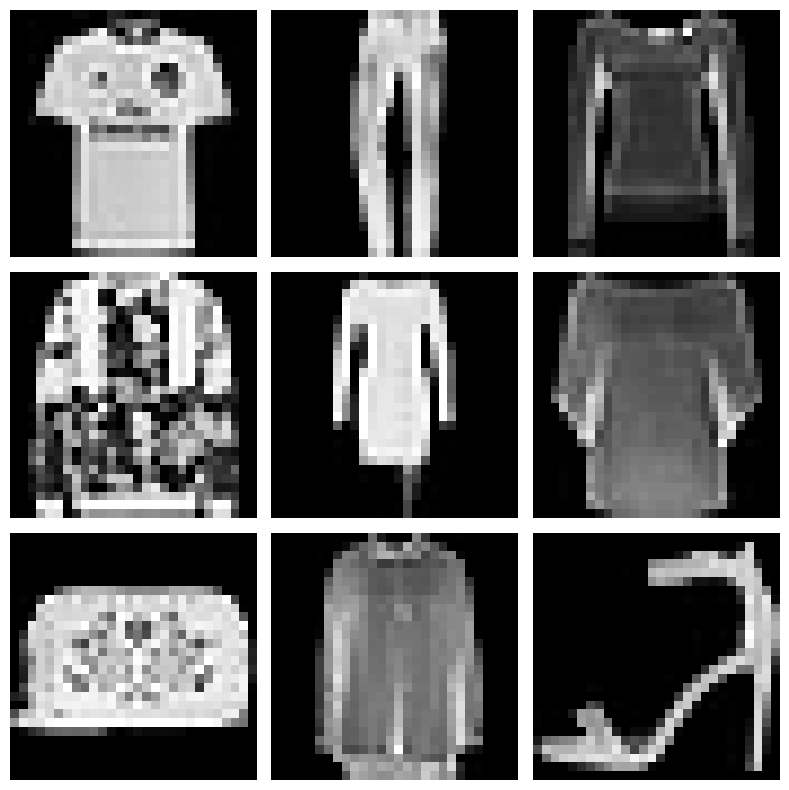

In [48]:
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Display the image; cmap='gray' is essential for 28x28 grayscale data
    plt.imshow(x_img[i], cmap='gray')

    # Optional: Show the label if you have them
    # plt.title(f"Label: {y_img[i].argmax()}")

    plt.axis('off')

plt.tight_layout()
plt.show()

In [59]:
img_to_predict = np.expand_dims(x_img[5], axis=0)

cnn.predict(img_to_predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[2.0268282e-01, 3.2575397e-05, 4.5837501e-01, 9.8622439e-04,
        1.7063113e-04, 1.1967813e-04, 3.3712214e-01, 7.3859923e-07,
        5.0599623e-04, 4.3061223e-06]], dtype=float32)

In [60]:
predicted_class = np.argmax(cnn.predict(img_to_predict))
confidence = np.max(cnn.predict(img_to_predict))
confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


np.float32(0.458375)

In [61]:
predicted_class

np.int64(2)